In [209]:
#Is there a relationship between the percentage of households using cars for transportation and the percentage of museums classified as art museums in North Carolina counties?

In [210]:
pip install python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [211]:
import os
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv, find_dotenv

In [212]:
load_dotenv()

True

In [213]:
api_key=os.getenv("CENSUS_API_KEY")

In [215]:
url = f"https://api.census.gov/data/2024/acs/acs1?get=NAME,B01001_001E&for=county:*&in=state:37&key={api_key}"

In [216]:
response = requests.get(url)

In [217]:
response.text

'[["NAME","B01001_001E","state","county"],\n["Alamance County, North Carolina","183040","37","001"],\n["Brunswick County, North Carolina","167112","37","019"],\n["Buncombe County, North Carolina","279210","37","021"],\n["Burke County, North Carolina","88545","37","023"],\n["Cabarrus County, North Carolina","244925","37","025"],\n["Caldwell County, North Carolina","80739","37","027"],\n["Carteret County, North Carolina","70259","37","031"],\n["Catawba County, North Carolina","167054","37","035"],\n["Chatham County, North Carolina","83874","37","037"],\n["Cleveland County, North Carolina","102194","37","045"],\n["Craven County, North Carolina","104167","37","049"],\n["Cumberland County, North Carolina","338430","37","051"],\n["Davidson County, North Carolina","177809","37","057"],\n["Durham County, North Carolina","343628","37","063"],\n["Forsyth County, North Carolina","398143","37","067"],\n["Franklin County, North Carolina","79771","37","069"],\n["Gaston County, North Carolina","24201

In [218]:
data = response.json()

In [219]:
data

[['NAME', 'B01001_001E', 'state', 'county'],
 ['Alamance County, North Carolina', '183040', '37', '001'],
 ['Brunswick County, North Carolina', '167112', '37', '019'],
 ['Buncombe County, North Carolina', '279210', '37', '021'],
 ['Burke County, North Carolina', '88545', '37', '023'],
 ['Cabarrus County, North Carolina', '244925', '37', '025'],
 ['Caldwell County, North Carolina', '80739', '37', '027'],
 ['Carteret County, North Carolina', '70259', '37', '031'],
 ['Catawba County, North Carolina', '167054', '37', '035'],
 ['Chatham County, North Carolina', '83874', '37', '037'],
 ['Cleveland County, North Carolina', '102194', '37', '045'],
 ['Craven County, North Carolina', '104167', '37', '049'],
 ['Cumberland County, North Carolina', '338430', '37', '051'],
 ['Davidson County, North Carolina', '177809', '37', '057'],
 ['Durham County, North Carolina', '343628', '37', '063'],
 ['Forsyth County, North Carolina', '398143', '37', '067'],
 ['Franklin County, North Carolina', '79771', '37'

In [220]:
dfcsv = pd.read_csv(r"C:\Users\allis\Downloads\nc_county_art_pct.csv")

dfcsv.head()

,county,percent_art_museum,museum_count,art_museum_count
0,Alamance,0.0,11,0
1,Alexander,0.0,3,0
2,Alleghany,0.0,2,0
3,Anson,0.0,2,0
4,Ashe,0.0,4,0


In [221]:
variables = ",".join([
    "NAME",            # County name
    "B01003_001E",     # Total population
    "B08141_001E",     # Total: Means of Transportation to Work by Vehicles Available (People that drive)
    "B08141_016E",     # Estimate!!Total:!!Public transportation:
    "B08141_017E",     # Estimate!!Total:!!Public transportation:!!No vehicle available
    "B08141_021E",     #Estimate!!Total:!!Walked:

])

url = f"https://api.census.gov/data/2024/acs/acs1?get={variables}&for=county:*&in=state:37&key={api_key}"

response = requests.get(url)

data = response.json()

df = pd.DataFrame(data[1:], columns=data[0])

print(df.isnull().sum())

df

NAME            0
B01003_001E     0
B08141_001E    26
B08141_016E    26
B08141_017E    26
B08141_021E    26
state           0
county          0
dtype: int64


,NAME,B01003_001E,B08141_001E,B08141_016E,B08141_017E,B08141_021E,state,county
0,"Alamance County, North Carolina",183040,87390,353,0,1298,37,001
1,"Brunswick County, North Carolina",167112,None,None,None,None,37,019
2,"Buncombe County, North Carolina",279210,129951,367,0,2047,37,021
3,"Burke County, North Carolina",88545,None,None,None,None,37,023
4,"Cabarrus County, North Carolina",244925,122994,990,0,1378,37,025
5,"Caldwell County, North Carolina",80739,None,None,None,None,37,027
6,"Carteret County, North Carolina",70259,None,None,None,None,37,031
7,"Catawba County, North Carolina",167054,None,None,None,None,37,035
8,"Chatham County, North Carolina",83874,None,None,None,None,37,037
9,"Cleveland County, North Carolina",102194,None,None,None,None,37,045


In [222]:
df.to_csv("census_data.csv", index=False)

df.head()

,NAME,B01003_001E,B08141_001E,B08141_016E,B08141_017E,B08141_021E,state,county
0,"Alamance County, North Carolina",183040,87390,353,0,1298,37,001
1,"Brunswick County, North Carolina",167112,None,None,None,None,37,019
2,"Buncombe County, North Carolina",279210,129951,367,0,2047,37,021
3,"Burke County, North Carolina",88545,None,None,None,None,37,023
4,"Cabarrus County, North Carolina",244925,122994,990,0,1378,37,025


In [ ]:
# Makes the values of the API dataset numerical for proper plotting

numeric_cols = [
    #"NAME",            # County name
    "B01003_001E",     # Total population
    "B08141_001E",     # Total: Means of Transportation to Work by Vehicles Available (People that drive)
    "B08141_016E",     # Estimate!!Total:!!Public transportation:
    "B08141_017E",     # Estimate!!Total:!!Public transportation:!!No vehicle available
    "B08141_021E"      #Estimate!!Total:!!Walks:
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce") # Will turn anything that can not become numerical into NaN


# Renames columns for a more clear understanding

df = df.rename(columns={
    #"NAME": "County_Name",
    "B01003_001E": "Total_Population",
    "B08141_001E": "Total_Transp_By_Vehicles_Available",
    "B08141_016E": "Total_Public_Transp",
    "B08141_017E": "No_Vehicle_Available",
    "B08141_021E": "Walks"
})

df.head()

,NAME,Total_Population,Total_Transp_By_Vehicles_Available,Total_Public_Transp,No_Vehicle_Available,Walks,state,county
0,"Alamance County, North Carolina",183040,87390.0,353.0,0.0,1298.0,37,001
1,"Brunswick County, North Carolina",167112,NaN,NaN,NaN,NaN,37,019
2,"Buncombe County, North Carolina",279210,129951.0,367.0,0.0,2047.0,37,021
3,"Burke County, North Carolina",88545,NaN,NaN,NaN,NaN,37,023
4,"Cabarrus County, North Carolina",244925,122994.0,990.0,0.0,1378.0,37,025


In [224]:
County_names = list(df['NAME'])
counties = list(dfcsv['county'])



In [225]:
# Makes the datasets match the format of their county columns
filtered_list = [item.split(" County")[0] for item in County_names]

dfcsv_filtered = dfcsv[dfcsv['county'].isin(filtered_list)]

print(dfcsv_filtered)

len(dfcsv_filtered)

df['NAME'] = filtered_list


         county  percent_art_museum  museum_count  art_museum_count
0      Alamance                0.00            11                 0
9     Brunswick                0.00             7                 0
10     Buncombe                8.00            25                 2
11        Burke                0.00             9                 0
12     Cabarrus                0.00             8                 0
13     Caldwell               14.29             7                 1
14     Carteret                0.00             9                 0
16      Catawba                6.67            15                 1
17      Chatham               25.00             4                 1
21    Cleveland                0.00             7                 0
23       Craven                7.69            13                 1
24   Cumberland                5.26            19                 1
27     Davidson               14.29             7                 1
30       Durham               11.54            2

In [226]:
len(df)
df.head()

,NAME,Total_Population,Total_Transp_By_Vehicles_Available,Total_Public_Transp,No_Vehicle_Available,Walks,state,county
0,Alamance,183040,87390.0,353.0,0.0,1298.0,37,001
1,Brunswick,167112,NaN,NaN,NaN,NaN,37,019
2,Buncombe,279210,129951.0,367.0,0.0,2047.0,37,021
3,Burke,88545,NaN,NaN,NaN,NaN,37,023
4,Cabarrus,244925,122994.0,990.0,0.0,1378.0,37,025


In [227]:


df: pd.DataFrame = df.merge(
    right = dfcsv_filtered, # The other dataframe being merged
    left_on = ["NAME"], # Names of the column in the left dataframe we would like to merge on
    right_on = ["county"], # Names of the column in the right dataframe we would like to merge on
    how = "right" # Type of merge
)

df.head()

,NAME,Total_Population,Total_Transp_By_Vehicles_Available,Total_Public_Transp,No_Vehicle_Available,Walks,state,county_x,county_y,percent_art_museum,museum_count,art_museum_count
0,Alamance,183040,87390.0,353.0,0.0,1298.0,37,001,Alamance,0.0,11,0
1,Brunswick,167112,NaN,NaN,NaN,NaN,37,019,Brunswick,0.0,7,0
2,Buncombe,279210,129951.0,367.0,0.0,2047.0,37,021,Buncombe,8.0,25,2
3,Burke,88545,NaN,NaN,NaN,NaN,37,023,Burke,0.0,9,0
4,Cabarrus,244925,122994.0,990.0,0.0,1378.0,37,025,Cabarrus,0.0,8,0


In [228]:
df.isnull().sum()

NAME                                   0
Total_Population                       0
Total_Transp_By_Vehicles_Available    26
Total_Public_Transp                   26
No_Vehicle_Available                  26
Walks                                 26
state                                  0
county_x                               0
county_y                               0
percent_art_museum                     0
museum_count                           0
art_museum_count                       0
dtype: int64

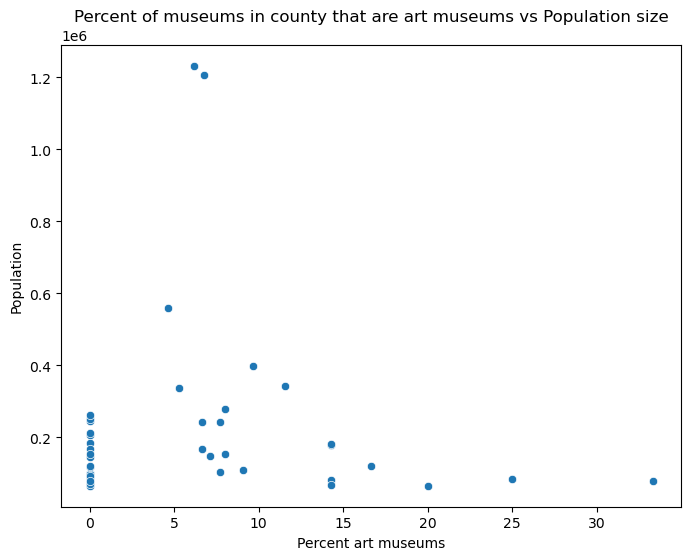

In [238]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="percent_art_museum", y="Total_Population")
plt.title("Percent of museums in county that are art museums vs Population size")
plt.xlabel("Percent art museums")
plt.ylabel("Population")
plt.show()

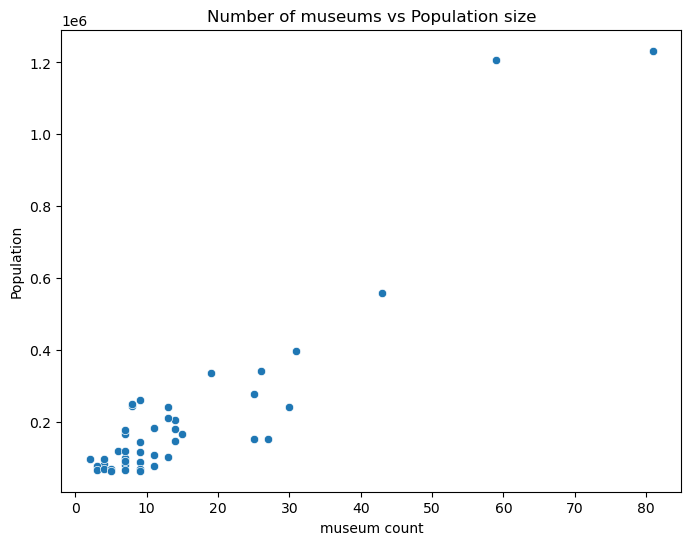

In [230]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="museum_count", y="Total_Population")
plt.title("Number of museums vs Population size")
plt.xlabel("museum count")
plt.ylabel("Population")
plt.show()

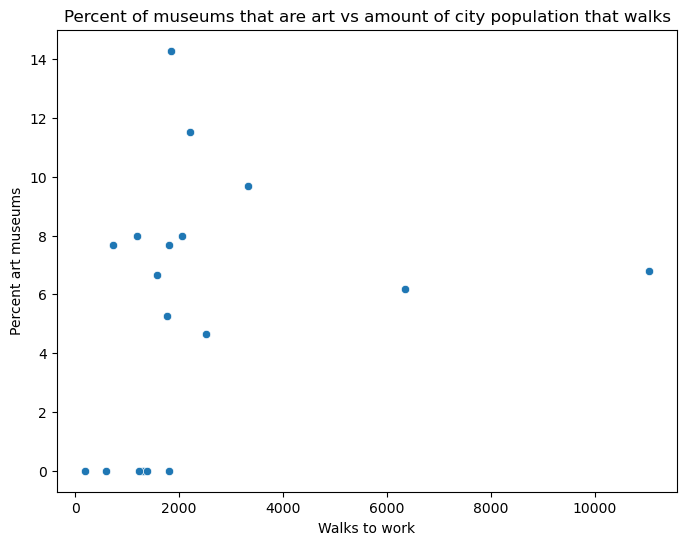

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="Walks", y="percent_art_museum")
plt.title("Percent of museums that are art vs amountof city population that walks")
plt.xlabel("Walks to work")
plt.ylabel("Percent art museums")
plt.show()

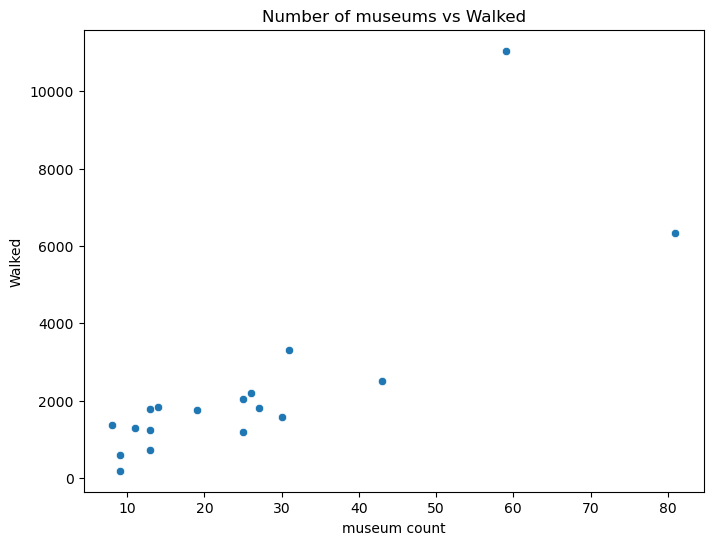

In [232]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="museum_count", y="Walks")
plt.title("Number of museums vs Walked")
plt.xlabel("museum count")
plt.ylabel("Walked")
plt.show()

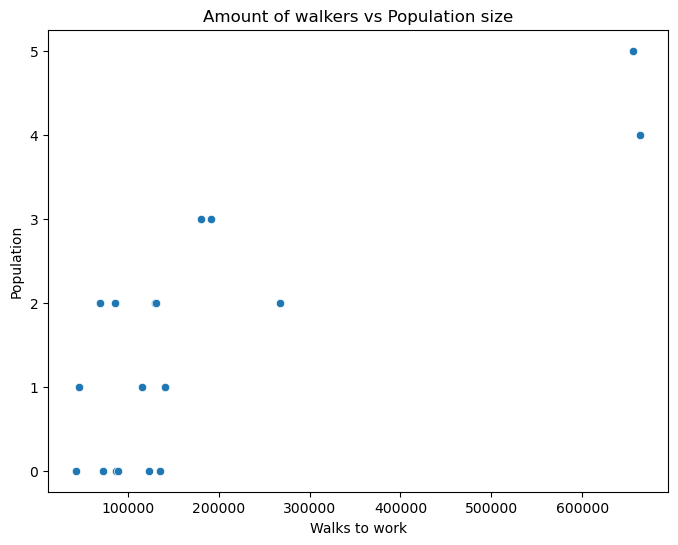

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="Total_Transp_By_Vehicles_Available", y="art_museum_count")
plt.title("meow")
plt.xlabel("meow")
plt.ylabel("mewow")
plt.show()

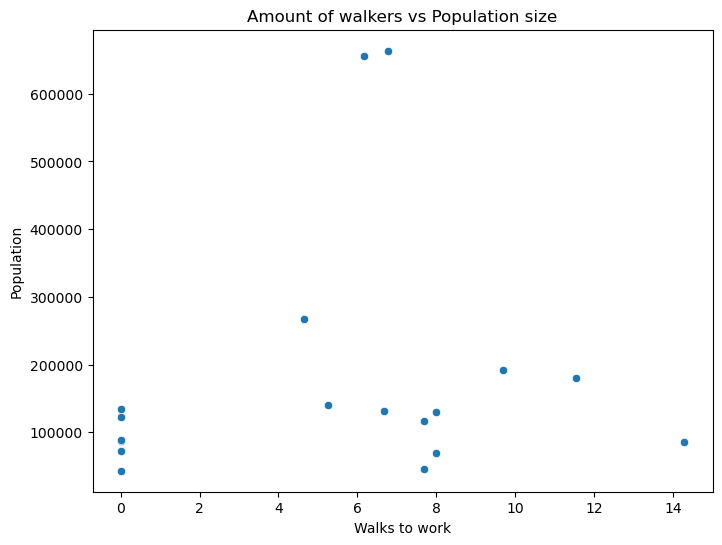

In [243]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="percent_art_museum", y="Total_Transp_By_Vehicles_Available")
plt.title("Amount of walkers vs Population size")
plt.xlabel("Walks to work")
plt.ylabel("Population")
plt.show()

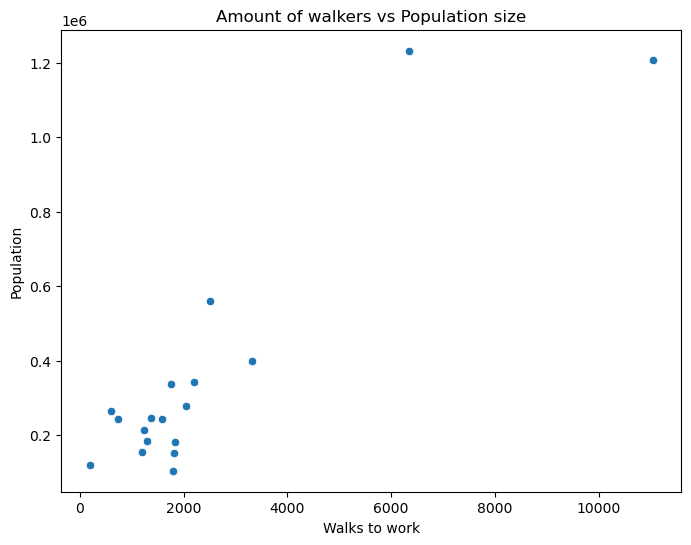

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="Walks", y="Total_Population")
plt.title("Amount of walkers vs Population size")
plt.xlabel("Walks to work")
plt.ylabel("Population")
plt.show()
# Shows if the correlation between walkers and population size could be the reason for correlation between art museums and walkers

In [234]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="Total_Public_Transportation", y="Walks")
plt.title("Total Public Transportation vs Walked to Work (NC Counties)")
plt.xlabel("Total Public Transportation")
plt.ylabel("Walked to Work")
plt.show()

ValueError: Could not interpret value `Total_Public_Transportation` for `x`. An entry with this name does not appear in `data`.

<Figure size 800x600 with 0 Axes>

In [235]:
plt.figure(figsize=(8,6))
sns.histplot(df[""], bins=20)
plt.title("")
plt.xlabel("")
plt.ylabel("")
plt.show()

KeyError: ''

<Figure size 800x600 with 0 Axes>

In [ ]:
#everything is far more related to population size rather than one transportation and the arts